# Start coding and Enjoy the journey

## Install the repo

In [ ]:
!git clone --recursive https://github.com/FarInHeight/Visual-Place-Recognition-Project.git

Cloning into 'Visual-Place-Recognition-Project'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 107 (delta 1), reused 0 (delta 0), pack-reused 88 (from 1)
Receiving objects: 100% (107/107), 1.34 MiB | 18.30 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Submodule 'image-matching-models' (https://github.com/alexstoken/image-matching-models.git) registered for path 'image-matching-models'
Cloning into '/content/Visual-Place-Recognition-Project/image-matching-models'...
remote: Enumerating objects: 1718, done.        
remote: Counting objects: 100% (895/895), done.        
remote: Compressing objects: 100% (340/340), done.        
remote: Total 1718 (delta 634), reused 622 (delta 554), pack-reused 823 (from 1)        
Receiving objects: 100% (1718/1718), 88.56 MiB | 48.26 MiB/s, done.
Resolving deltas: 100% (1173/1173), done.
Submodule path 'image-matching-models': checked out '0079bf

/tmp/ipython-input-1885827366.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  corrected_auc = cov[0] + np.trapz(saf, cov)


Grafico generato: precision_coverage_corrected.png


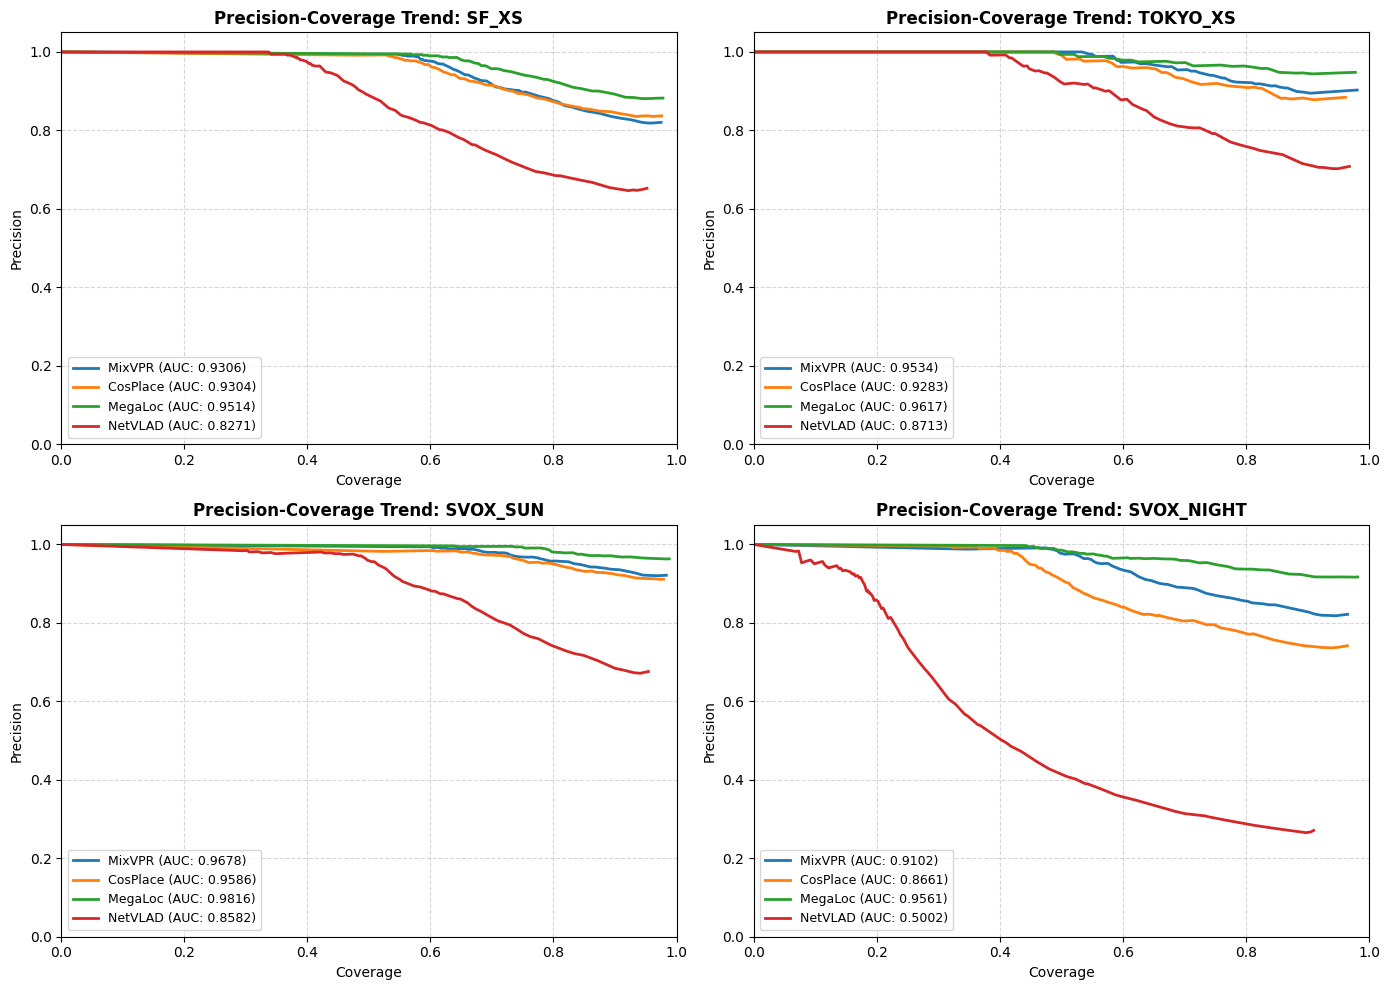

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import re

def generate_vpr_plots(file_path):
    with open(file_path, 'r') as f:
        content = f.read()

    blocks = re.split(r'-{10,}', content)
    data = []

    for block in blocks:
        if 'Configurazione' not in block: continue

        config = re.search(r'Configurazione:\s*(.*)', block).group(1).strip()
        cov = [float(x) for x in re.search(r'COV:\s*\[(.*?)\]', block, re.DOTALL).group(1).split(',')]
        saf = [float(x) for x in re.search(r'SAF:\s*\[(.*?)\]', block, re.DOTALL).group(1).split(',')]

        # Calcolo AUC Corretta: Area Safe Zone (0 a COV[0]) + Trapz (COV a 1.0)
        corrected_auc = cov[0] + np.trapz(saf, cov)
        data.append({'config': config, 'cov': cov, 'saf': saf, 'auc': corrected_auc})

    datasets = ['SF_XS', 'TOKYO_XS', 'SVOX_SUN', 'SVOX_NIGHT']
    methods_order = ['MixVPR', 'CosPlace', 'MegaLoc', 'NetVLAD']
    colors = {'MixVPR': '#1f77b4', 'CosPlace': '#ff7f0e', 'MegaLoc': '#2ca02c', 'NetVLAD': '#d62728'}

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()

    for i, ds in enumerate(datasets):
        ax = axs[i]
        ax.set_title(f'Precision-Coverage Trend: {ds}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Coverage'), ax.set_ylabel('Precision')
        ax.set_ylim(0, 1.05), ax.set_xlim(0, 1.0)
        ax.grid(True, linestyle='--', alpha=0.5)

        ds_entries = [d for d in data if ds.lower() in d['config'].lower()]
        ds_entries.sort(key=lambda x: [m.lower() in x['config'].lower() for m in methods_order].index(True))

        for entry in ds_entries:
            method = next(m for m in methods_order if m.lower() in entry['config'].lower())
            # Inserimento del punto (0, 1) per la Safe Zone
            x, y = [0] + entry['cov'], [1.0] + entry['saf']
            ax.plot(x, y, label=f'{method} (AUC: {entry["auc"]:.4f})', color=colors[method], linewidth=2)

        ax.legend(loc='lower left', fontsize=9, frameon=True)

    plt.tight_layout()
    plt.savefig('precision_coverage_corrected.png', dpi=300)
    print("Grafico generato: precision_coverage_corrected.png")

# Esecuzione
generate_vpr_plots('risultati_finali-4.txt')

In [ ]:
!ls

sample_data  Visual-Place-Recognition-Project


In [ ]:
%cd Visual-Place-Recognition-Project

/content/Visual-Place-Recognition-Project


In [ ]:
%pwd

'/content/Visual-Place-Recognition-Project'

## Install dependencies

In [ ]:
%cd image-matching-models


/content/Visual-Place-Recognition-Project/image-matching-models


In [ ]:
!pip install -e .

Obtaining file:///content/Visual-Place-Recognition-Project/image-matching-models
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.3/225.3 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 737.0/737.0 kB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.3 MB/s eta 0:00:00
  Buildi

In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 122.7 MB/s eta 0:00:00


In [ ]:
%cd /content/Visual-Place-Recognition-Project


/content/Visual-Place-Recognition-Project


In [ ]:
!ls


download_datasets.py	README.md		  VPR-methods-evaluation
image-matching-models	reranking.py		  vpr_uncertainty
LICENSE			start_your_project.ipynb
match_queries_preds.py	util.py


In [ ]:
!pwd

/content/Visual-Place-Recognition-Project


## Download Datasets

In [ ]:
!python download_datasets.py

Downloading...
From (original): https://drive.google.com/uc?id=15QB3VNKj93027UAQWv7pzFQO1JDCdZj2
From (redirected): https://drive.google.com/uc?id=15QB3VNKj93027UAQWv7pzFQO1JDCdZj2&confirm=t&uuid=90b27503-7c4b-4490-aaa2-0192407b3f96
To: /content/Visual-Place-Recognition-Project/data/tokyo_xs.zip
100% 141M/141M [00:00<00:00, 144MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1tQqEyt3go3vMh4fj_LZrRcahoTbzzH-y
From (redirected): https://drive.google.com/uc?id=1tQqEyt3go3vMh4fj_LZrRcahoTbzzH-y&confirm=t&uuid=299233c5-d87d-4aff-be14-fe6c1a5be666
To: /content/Visual-Place-Recognition-Project/data/sf_xs.zip
100% 1.03G/1.03G [00:07<00:00, 143MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1q7usSe9_5xV5zTfN-1In4DlmF5ReyU_A
From (redirected): https://drive.google.com/uc?id=1q7usSe9_5xV5zTfN-1In4DlmF5ReyU_A&confirm=t&uuid=bea208a7-c946-4a8c-9f3a-0d6ff45a8b41
To: /content/Visual-Place-Recognition-Project/data/gsv_xs.zip
100% 5.67G/5.67G [00:45<00:00, 126MB

In [ ]:
%pwd

'/content/Visual-Place-Recognition-Project'

## Run your First VPR Evalutation



In [ ]:
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir log_dir \
--method=netvlad --backbone=VGG16 --descriptors_dimension=4096 \
--image_size 512 512 \
--database_folder data/sf_xs/test/database \
--queries_folder data/sf_xs/test/queries \
--distance_metric L2 \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

2025-12-14 14:41:14 VPR-methods-evaluation/main.py --num_workers 8 --batch_size 32 --log_dir log_dir --method=netvlad --backbone=VGG16 --descriptors_dimension=4096 --image_size 512 512 --database_folder data/tokyo_xs/test/database --queries_folder data/tokyo_xs/test/queries --distance_metric L2 --num_preds_to_save 20 --recall_values 1 5 10 20 --save_for_uncertainty
2025-12-14 14:41:14 Arguments: Namespace(positive_dist_threshold=25, method='netvlad', backbone='VGG16', descriptors_dimension=4096, database_folder='data/tokyo_xs/test/database', queries_folder='data/tokyo_xs/test/queries', num_workers=8, batch_size=32, log_dir='log_dir', device='cuda', recall_values=[1, 5, 10, 20], no_labels=False, num_preds_to_save=20, save_only_wrong_preds=False, image_size=[512, 512], save_descriptors=False, save_for_uncertainty=True, distance_metric='L2', use_labels=True)
2025-12-14 14:41:14 Testing with netvlad with a VGG16 backbone and descriptors dimension 4096
2025-12-14 14:41:14 The outputs are be

## Run Image Matching on Retrieval Results



In [ ]:
!python match_queries_preds.py \
--preds-dir '<path-to-predictions-folder>' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

## Check Re-ranking Performance

In [ ]:
!python reranking.py \
--preds-dir '<path-to-predictions-folder>' \
--inliers-dir '<path-to-inliers-folder>' \
--num-preds 20 \
--recall-values 1 5 10 20

## Perform Uncertainty Evalutation

In [ ]:
!python -m vpr_uncertainty.eval \
--preds-dir '<path-to-predictions-folder>' \
--inliers-dir '<path-to-inliers-folder>' \
--z-data-path '<path-to-z-data-file>'

# TASK 1: Image retrieval

In [ ]:
# Metodo NetVLAD con backbone VGG16 descrittore con dimensione 4096 metrica distanza L2
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir netvlad_VGG16_tokyo_xs_L2 \
--method=netvlad --backbone=VGG16 --descriptors_dimension=4096 \
--image_size 512 512 \
--database_folder data/tokyo_xs/test/database \
--queries_folder data/tokyo_xs/test/queries \
--distance_metric L2 \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

python3: can't open file '/content/VPR-methods-evaluation/main.py': [Errno 2] No such file or directory


In [ ]:
# Metodo NetVLAD con backbone VGG16 descrittore con dimensione 4096 metrica distanza cosine similarity
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir netvlad_VGG16_tokyo_xs_cosine \
--method=netvlad --backbone=VGG16 --descriptors_dimension=4096 \
--image_size 512 512 \
--database_folder data/tokyo_xs/test/database \
--queries_folder data/tokyo_xs/test/queries \
--distance_metric dot_product \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

python3: can't open file '/content/VPR-methods-evaluation/main.py': [Errno 2] No such file or directory


In [ ]:
# Metodo MixVPR backbone ResNet50 metrica L2
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir mixvpr_ResNet50_tokyo_xs_L2 \
--method=mixvpr --backbone=ResNet50 --descriptors_dimension=4096 \
--image_size 512 512 \
--database_folder data/tokyo_xs/test/database \
--queries_folder data/tokyo_xs/test/queries \
--distance_metric L2 \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

python3: can't open file '/content/VPR-methods-evaluation/main.py': [Errno 2] No such file or directory


In [ ]:
# Metodo MixVPR backbone ResNet50 metrica cosine similarity
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir mixvpr_ResNet50_tokyo_xs_cosine \
--method=mixvpr --backbone=ResNet50 --descriptors_dimension=4096 \
--image_size 512 512 \
--database_folder data/tokyo_xs/test/database \
--queries_folder data/tokyo_xs/test/queries \
--distance_metric dot_product \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

python3: can't open file '/content/VPR-methods-evaluation/main.py': [Errno 2] No such file or directory


In [ ]:
# Metodo MegaLOC backbone Dinov2 metrica L2
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir megaloc_Dinov2_tokyo_xs_L2 \
--method=megaloc --backbone=Dinov2 --descriptors_dimension=8448 \
--image_size 512 512 \
--database_folder data/tokyo_xs/test/database \
--queries_folder data/tokyo_xs/test/queries \
--distance_metric L2 \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

python3: can't open file '/content/VPR-methods-evaluation/main.py': [Errno 2] No such file or directory


In [ ]:
# Metodo MegaLOC backbone Dinov2 metrica cosine
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir megaloc_Dinov2_tokyo_xs_cosine \
--method=megaloc --backbone=Dinov2 --descriptors_dimension=8448 \
--image_size 512 512 \
--database_folder data/tokyo_xs/test/database \
--queries_folder data/tokyo_xs/test/queries \
--distance_metric dot_product \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

python3: can't open file '/content/VPR-methods-evaluation/main.py': [Errno 2] No such file or directory


In [ ]:
# Metodo Cosplace backbone ResNet50 metrica L2
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir cosplace_ResNet50_tokyo_xs_L2 \
--method=cosplace --backbone=ResNet50 --descriptors_dimension=2048 \
--image_size 512 512 \
--database_folder data/tokyo_xs/test/database \
--queries_folder data/tokyo_xs/test/queries \
--distance_metric L2 \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

python3: can't open file '/content/VPR-methods-evaluation/main.py': [Errno 2] No such file or directory


In [ ]:
# Metodo Cosplace backbone ResNet50 metrica cosine
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir cosplace_ResNet50_tokyo_xs_cosine \
--method=cosplace --backbone=ResNet50 --descriptors_dimension=2048 \
--image_size 512 512 \
--database_folder data/tokyo_xs/test/database \
--queries_folder data/tokyo_xs/test/queries \
--distance_metric dot_product \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

python3: can't open file '/content/VPR-methods-evaluation/main.py': [Errno 2] No such file or directory


In [ ]:
# DATASET SF_XS
#netvlad con sf_xs metrica l2
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir netvlad_VGG16_sf_xs_L2 \
--method=netvlad --backbone=VGG16 --descriptors_dimension=4096 \
--image_size 512 512 \
--database_folder data/sf_xs/test/database \
--queries_folder data/sf_xs/test/queries \
--distance_metric L2 \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

2025-12-25 16:54:49 VPR-methods-evaluation/main.py --num_workers 8 --batch_size 32 --log_dir netvlad_VGG16_sf_xs_L2 --method=netvlad --backbone=VGG16 --descriptors_dimension=4096 --image_size 512 512 --database_folder data/sf_xs/test/database --queries_folder data/sf_xs/test/queries --distance_metric L2 --num_preds_to_save 20 --recall_values 1 5 10 20 --save_for_uncertainty
2025-12-25 16:54:49 Arguments: Namespace(positive_dist_threshold=25, method='netvlad', backbone='VGG16', descriptors_dimension=4096, database_folder='data/sf_xs/test/database', queries_folder='data/sf_xs/test/queries', num_workers=8, batch_size=32, log_dir='netvlad_VGG16_sf_xs_L2', device='cuda', recall_values=[1, 5, 10, 20], no_labels=False, num_preds_to_save=20, save_only_wrong_preds=False, image_size=[512, 512], save_descriptors=False, save_for_uncertainty=True, distance_metric='L2', use_labels=True)
2025-12-25 16:54:49 Testing with netvlad with a VGG16 backbone and descriptors dimension 4096
2025-12-25 16:54:49 

In [ ]:
# Metodo MixVPR backbone ResNet50 metrica L2
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir mixvpr_ResNet50_sf_xs_L2 \
--method=mixvpr --backbone=ResNet50 --descriptors_dimension=4096 \
--image_size 512 512 \
--database_folder data/sf_xs/test/database \
--queries_folder data/sf_xs/test/queries \
--distance_metric L2 \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

2025-12-25 17:14:24 VPR-methods-evaluation/main.py --num_workers 8 --batch_size 32 --log_dir mixvpr_ResNet50_sf_xs_L2 --method=mixvpr --backbone=ResNet50 --descriptors_dimension=4096 --image_size 512 512 --database_folder data/sf_xs/test/database --queries_folder data/sf_xs/test/queries --distance_metric L2 --num_preds_to_save 20 --recall_values 1 5 10 20 --save_for_uncertainty
2025-12-25 17:14:24 Arguments: Namespace(positive_dist_threshold=25, method='mixvpr', backbone='ResNet50', descriptors_dimension=4096, database_folder='data/sf_xs/test/database', queries_folder='data/sf_xs/test/queries', num_workers=8, batch_size=32, log_dir='mixvpr_ResNet50_sf_xs_L2', device='cuda', recall_values=[1, 5, 10, 20], no_labels=False, num_preds_to_save=20, save_only_wrong_preds=False, image_size=[512, 512], save_descriptors=False, save_for_uncertainty=True, distance_metric='L2', use_labels=True)
2025-12-25 17:14:24 Testing with mixvpr with a ResNet50 backbone and descriptors dimension 4096
2025-12-25

In [ ]:
# Metodo MegaLOC backbone Dinov2 metrica L2
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir megaloc_Dinov2_sf_xs_L2 \
--method=megaloc --backbone=Dinov2 --descriptors_dimension=8448 \
--image_size 512 512 \
--database_folder data/sf_xs/test/database \
--queries_folder data/sf_xs/test/queries \
--distance_metric L2 \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

2025-12-25 17:25:53 VPR-methods-evaluation/main.py --num_workers 8 --batch_size 32 --log_dir megaloc_Dinov2_sf_xs_L2 --method=megaloc --backbone=Dinov2 --descriptors_dimension=8448 --image_size 512 512 --database_folder data/sf_xs/test/database --queries_folder data/sf_xs/test/queries --distance_metric L2 --num_preds_to_save 20 --recall_values 1 5 10 20 --save_for_uncertainty
2025-12-25 17:25:53 Arguments: Namespace(positive_dist_threshold=25, method='megaloc', backbone='Dinov2', descriptors_dimension=8448, database_folder='data/sf_xs/test/database', queries_folder='data/sf_xs/test/queries', num_workers=8, batch_size=32, log_dir='megaloc_Dinov2_sf_xs_L2', device='cuda', recall_values=[1, 5, 10, 20], no_labels=False, num_preds_to_save=20, save_only_wrong_preds=False, image_size=[512, 512], save_descriptors=False, save_for_uncertainty=True, distance_metric='L2', use_labels=True)
2025-12-25 17:25:53 Testing with megaloc with a Dinov2 backbone and descriptors dimension 8448
2025-12-25 17:2

In [ ]:
# Metodo Cosplace backbone ResNet50 metrica L2
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir cosplace_ResNet50_sf_xs_L2 \
--method=cosplace --backbone=ResNet50 --descriptors_dimension=2048 \
--image_size 512 512 \
--database_folder data/sf_xs/test/database \
--queries_folder data/sf_xs/test/queries \
--distance_metric L2 \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

2025-12-25 18:18:31 VPR-methods-evaluation/main.py --num_workers 8 --batch_size 32 --log_dir cosplace_ResNet50_sf_xs_L2 --method=cosplace --backbone=ResNet50 --descriptors_dimension=2048 --image_size 512 512 --database_folder data/sf_xs/test/database --queries_folder data/sf_xs/test/queries --distance_metric L2 --num_preds_to_save 20 --recall_values 1 5 10 20 --save_for_uncertainty
2025-12-25 18:18:31 Arguments: Namespace(positive_dist_threshold=25, method='cosplace', backbone='ResNet50', descriptors_dimension=2048, database_folder='data/sf_xs/test/database', queries_folder='data/sf_xs/test/queries', num_workers=8, batch_size=32, log_dir='cosplace_ResNet50_sf_xs_L2', device='cuda', recall_values=[1, 5, 10, 20], no_labels=False, num_preds_to_save=20, save_only_wrong_preds=False, image_size=[512, 512], save_descriptors=False, save_for_uncertainty=True, distance_metric='L2', use_labels=True)
2025-12-25 18:18:31 Testing with cosplace with a ResNet50 backbone and descriptors dimension 2048


In [ ]:
# DATASET SVOX
# netvlad con backbone VGG16 metrica l2
!python VPR-methods-evaluation/main.py \
  --num_workers 8 \
  --batch_size 32 \
  --log_dir netvlad_VGG16_svox_L2 \
  --method=netvlad --backbone=VGG16 --descriptors_dimension=4096 \
  --image_size 512 512 \
  --database_folder data/svox/images/test/gallery \
  --queries_folder data/svox/images/test/queries \
  --distance_metric L2 \
  --num_preds_to_save 20 \
  --recall_values 1 5 10 20 \
  --save_for_uncertainty

2025-12-26 13:49:31 VPR-methods-evaluation/main.py --num_workers 8 --batch_size 32 --log_dir netvlad_VGG16_svox_L2 --method=netvlad --backbone=VGG16 --descriptors_dimension=4096 --image_size 512 512 --database_folder data/svox/images/test/gallery --queries_folder data/svox/images/test/queries --distance_metric L2 --num_preds_to_save 20 --recall_values 1 5 10 20 --save_for_uncertainty
2025-12-26 13:49:31 Arguments: Namespace(positive_dist_threshold=25, method='netvlad', backbone='VGG16', descriptors_dimension=4096, database_folder='data/svox/images/test/gallery', queries_folder='data/svox/images/test/queries', num_workers=8, batch_size=32, log_dir='netvlad_VGG16_svox_L2', device='cuda', recall_values=[1, 5, 10, 20], no_labels=False, num_preds_to_save=20, save_only_wrong_preds=False, image_size=[512, 512], save_descriptors=False, save_for_uncertainty=True, distance_metric='L2', use_labels=True)
2025-12-26 13:49:31 Testing with netvlad with a VGG16 backbone and descriptors dimension 4096


In [ ]:
# Metodo MixVPR backbone ResNet50 metrica L2
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir mixvpr_ResNet50_svox_L2 \
--method=mixvpr --backbone=ResNet50 --descriptors_dimension=4096 \
--image_size 512 512 \
--database_folder data/svox/images/test/gallery \
--queries_folder data/svox/images/test/queries \
--distance_metric L2 \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

2025-12-26 10:54:48 VPR-methods-evaluation/main.py --num_workers 8 --batch_size 32 --log_dir mixvpr_ResNet50_svox_L2 --method=mixvpr --backbone=ResNet50 --descriptors_dimension=4096 --image_size 512 512 --database_folder data/svox/images/test/gallery --queries_folder data/svox/images/test/queries --distance_metric L2 --num_preds_to_save 20 --recall_values 1 5 10 20 --save_for_uncertainty
2025-12-26 10:54:48 Arguments: Namespace(positive_dist_threshold=25, method='mixvpr', backbone='ResNet50', descriptors_dimension=4096, database_folder='data/svox/images/test/gallery', queries_folder='data/svox/images/test/queries', num_workers=8, batch_size=32, log_dir='mixvpr_ResNet50_svox_L2', device='cuda', recall_values=[1, 5, 10, 20], no_labels=False, num_preds_to_save=20, save_only_wrong_preds=False, image_size=[512, 512], save_descriptors=False, save_for_uncertainty=True, distance_metric='L2', use_labels=True)
2025-12-26 10:54:48 Testing with mixvpr with a ResNet50 backbone and descriptors dimen

In [ ]:
# Metodo MegaLOC backbone Dinov2 metrica L2
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir megaloc_Dinov2_svox_L2 \
--method=megaloc --backbone=Dinov2 --descriptors_dimension=8448 \
--image_size 512 512 \
--database_folder data/svox/images/test/gallery \
--queries_folder data/svox/images/test/queries \
--distance_metric L2 \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

2025-12-26 11:53:12 VPR-methods-evaluation/main.py --num_workers 8 --batch_size 32 --log_dir megaloc_Dinov2_svox_L2 --method=megaloc --backbone=Dinov2 --descriptors_dimension=8448 --image_size 512 512 --database_folder data/svox/images/test/gallery --queries_folder data/svox/images/test/queries --distance_metric L2 --num_preds_to_save 20 --recall_values 1 5 10 20 --save_for_uncertainty
2025-12-26 11:53:12 Arguments: Namespace(positive_dist_threshold=25, method='megaloc', backbone='Dinov2', descriptors_dimension=8448, database_folder='data/svox/images/test/gallery', queries_folder='data/svox/images/test/queries', num_workers=8, batch_size=32, log_dir='megaloc_Dinov2_svox_L2', device='cuda', recall_values=[1, 5, 10, 20], no_labels=False, num_preds_to_save=20, save_only_wrong_preds=False, image_size=[512, 512], save_descriptors=False, save_for_uncertainty=True, distance_metric='L2', use_labels=True)
2025-12-26 11:53:12 Testing with megaloc with a Dinov2 backbone and descriptors dimension 

In [ ]:
# Metodo Cosplace backbone ResNet50 metrica L2
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir cosplace_ResNet50_svox_L2 \
--method=cosplace --backbone=ResNet50 --descriptors_dimension=2048 \
--image_size 512 512 \
--database_folder data/svox/images/test/gallery \
--queries_folder data/svox/images/test/queries \
--distance_metric L2 \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

2025-12-26 13:50:00 VPR-methods-evaluation/main.py --num_workers 8 --batch_size 32 --log_dir cosplace_ResNet50_svox_L2 --method=cosplace --backbone=ResNet50 --descriptors_dimension=2048 --image_size 512 512 --database_folder data/svox/images/test/gallery --queries_folder data/svox/images/test/queries --distance_metric L2 --num_preds_to_save 20 --recall_values 1 5 10 20 --save_for_uncertainty
2025-12-26 13:50:00 Arguments: Namespace(positive_dist_threshold=25, method='cosplace', backbone='ResNet50', descriptors_dimension=2048, database_folder='data/svox/images/test/gallery', queries_folder='data/svox/images/test/queries', num_workers=8, batch_size=32, log_dir='cosplace_ResNet50_svox_L2', device='cuda', recall_values=[1, 5, 10, 20], no_labels=False, num_preds_to_save=20, save_only_wrong_preds=False, image_size=[512, 512], save_descriptors=False, save_for_uncertainty=True, distance_metric='L2', use_labels=True)
2025-12-26 13:50:00 Testing with cosplace with a ResNet50 backbone and descrip

In [ ]:
# Metodo mixvpr backbone ResNet50 metrica L2
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--logs_svox_sun mixvpr_ResNet50_svox_test_L2 \
--method=cosplace --backbone=ResNet50 --descriptors_dimension=4096 \
--image_size 512 512 \
--database_folder data/svox/images/test/gallery \
--queries_folder data/svox/images/test/queries \
--distance_metric L2 \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

In [ ]:
import os
from google.colab import drive

# 1. Montaggio Drive (se non fatto)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Percorsi
source = '/content/Visual-Place-Recognition-Project/logs/'
dest = '/content/drive/MyDrive/logs_svox/'

# Crea la cartella di destinazione se manca
!mkdir -p "{dest}"

print("🚀 INIZIO COPIA TOTALE (RSYNC MODE)...")

# 3. RSYNC: Il metodo più potente
# -a: archive mode (mantiene sottocartelle e permessi)
# -v: verbose (ti mostra ogni singolo file che passa)
# -z: comprime durante il trasferimento
# --ignore-existing: se vuoi solo i file mancanti (opzionale)
!rsync -avz "{source}" "{dest}"

print("\n--- VERIFICA RECURSIVA ---")
# Controlliamo che dentro le cartelle ci siano i file (es. recall, pesi, log)
!find "{dest}" -maxdepth 2

🚀 INIZIO COPIA TOTALE (RSYNC MODE)...
sending incremental file list
./
.ipynb_checkpoints/
cosplace_ResNet50_svox_L2/
cosplace_ResNet50_svox_L2/2025-12-26_13-49-59/
cosplace_ResNet50_svox_L2/2025-12-26_13-49-59/preds/
cosplace_ResNet50_svox_L2/2025-12-26_13-49-59/preds/3144.txt
cosplace_ResNet50_svox_L2/2025-12-26_13-49-59/preds/3145.jpg
cosplace_ResNet50_svox_L2/2025-12-26_13-49-59/preds/3145.txt
cosplace_ResNet50_svox_L2/2025-12-26_13-49-59/preds/3146.jpg
cosplace_ResNet50_svox_L2/2025-12-26_13-49-59/preds/3146.txt
cosplace_ResNet50_svox_L2/2025-12-26_13-49-59/preds/3147.jpg
cosplace_ResNet50_svox_L2/2025-12-26_13-49-59/preds/3147.txt
cosplace_ResNet50_svox_L2/2025-12-26_13-49-59/preds/3148.jpg
cosplace_ResNet50_svox_L2/2025-12-26_13-49-59/preds/3148.txt
cosplace_ResNet50_svox_L2/2025-12-26_13-49-59/preds/3149.jpg
cosplace_ResNet50_svox_L2/2025-12-26_13-49-59/preds/3149.txt
cosplace_ResNet50_svox_L2/2025-12-26_13-49-59/preds/315.jpg
cosplace_ResNet50_svox_L2/2025-12-26_13-49-59/preds

In [ ]:
# 1. Assicuriamoci che Drive sia montato
from google.colab import drive
import os
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Definiamo i percorsi
sorgente = '/content/Visual-Place-Recognition-Project/logs'
nome_zip = 'backup_vpr_svox.zip'
percorso_zip_locale = f'/content/{nome_zip}'
destinazione_drive = f'/content/drive/MyDrive/{nome_zip}'

print("--- INIZIO COMPRESSIONE (Operazione locale su SSD) ---")
# Usiamo -q per non intasare l'output, o rimuovilo se vuoi vedere il progresso
!zip -r {percorso_zip_locale} {sorgente}

print("\n--- INIZIO COPIA SU DRIVE (Singolo file grande) ---")
!cp -v {percorso_zip_locale} {destinazione_drive}

print("\n✅ Operazione completata! Troverai il file .zip nella cartella principale del tuo Drive.")

Output streaming troncato alle ultime 5000 righe.
  adding: content/Visual-Place-Recognition-Project/logs/mixvpr_ResNet50_svox_L2/2025-12-26_10-54-48/preds/8209.jpg (deflated 11%)
  adding: content/Visual-Place-Recognition-Project/logs/mixvpr_ResNet50_svox_L2/2025-12-26_10-54-48/preds/13843.txt (deflated 77%)
  adding: content/Visual-Place-Recognition-Project/logs/mixvpr_ResNet50_svox_L2/2025-12-26_10-54-48/preds/4595.txt (deflated 72%)
  adding: content/Visual-Place-Recognition-Project/logs/mixvpr_ResNet50_svox_L2/2025-12-26_10-54-48/preds/257.jpg (deflated 7%)
  adding: content/Visual-Place-Recognition-Project/logs/mixvpr_ResNet50_svox_L2/2025-12-26_10-54-48/preds/386.jpg (deflated 8%)
  adding: content/Visual-Place-Recognition-Project/logs/mixvpr_ResNet50_svox_L2/2025-12-26_10-54-48/preds/7213.txt (deflated 74%)
  adding: content/Visual-Place-Recognition-Project/logs/mixvpr_ResNet50_svox_L2/2025-12-26_10-54-48/preds/565.jpg (deflated 10%)
  adding: content/Visual-Place-Recognition-P

# TASK 2: Image matching Methods

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/Visual-Place-Recognition-Project

/content/Visual-Place-Recognition-Project


In [ ]:
# Assicurati di essere nella cartella del progetto
%cd /content/Visual-Place-Recognition-Project

# Crea i collegamenti simbolici corretti puntando alla cartella AML_VPR su Drive
!ln -sf "/content/drive/MyDrive/AML_VPR/logs_tokyo_xs" "logs_tokyo_xs"
!ln -sf "/content/drive/MyDrive/AML_VPR/logs_sf_xs" "logs_sf_xs"
!ln -sf "/content/drive/MyDrive/AML_VPR/logs_svox_sun" "logs_svox_sun"
!ln -sf "/content/drive/MyDrive/AML_VPR/logs_svox_night" "logs_svox_night"

# Verifica che i link siano attivi (appariranno in azzurro se corretti)
!ls -F

/content/Visual-Place-Recognition-Project
AUC_cosplace_ResNet50_tokyo_xs_L2.png  logs_svox_sun@
AUC_megaloc_Dinov2_tokyo_xs_L2.png     logs_tokyo_xs@
AUC_mixvpr_ResNet50_tokyo_xs_L2.png    mashup_tokyo_xs.png
AUC_netvlad_VGG16_tokyo_xs_L2.png      match_queries_preds.py
calibration.py			       README.md
data/				       reranking.py
download_datasets.py		       risultati_finali-3.txt
estensione-2.py			       start_your_project.ipynb
image-matching-models/		       util.py
LICENSE				       VPR-methods-evaluation/
logs_sf_xs@			       vpr_uncertainty/
logs_svox_night@


In [ ]:
#PARTI DA QUI 28/12
# TOKYO_XS DATASET
# netvlad method with superpoint + lightglue as matching method on tokyo_xs dataset
!python match_queries_preds.py \
--preds-dir 'logs_tokyo_xs/netvlad_VGG16_tokyo_xs_L2/2025-12-24_04-50-00/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 315/315 [00:00<00:00, 5741.88it/s]


In [ ]:
# netvlad method with LoFTR as matching method on tokyo_xs dataset
!python match_queries_preds.py \
--preds-dir 'logs_tokyo_xs/netvlad_VGG16_tokyo_xs_L2/2025-12-24_04-50-00/preds' \
--matcher 'loftr' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 315/315 [00:00<00:00, 5695.15it/s]


In [ ]:
# netvlad method with superglue matching method on tokyo_sx dataset
!python match_queries_preds.py \
--preds-dir 'logs_tokyo_xs/netvlad_VGG16_tokyo_xs_L2/2025-12-24_04-50-00/preds' \
--matcher 'superglue' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 315/315 [00:00<00:00, 5687.08it/s]


In [ ]:
# mixvpr method with superpoint + lightglue as matching method on tokyo_xs dataset
!python match_queries_preds.py \
--preds-dir 'logs_tokyo_xs/mixvpr_ResNet50_tokyo_xs_L2/2025-12-24_05-08-30/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 315/315 [00:00<00:00, 5460.27it/s]


In [ ]:
# mixvpr method with LoFTR as matching method on tokyo_xs dataset
!python match_queries_preds.py \
--preds-dir 'logs_tokyo_xs/mixvpr_ResNet50_tokyo_xs_L2/2025-12-24_05-08-30/preds' \
--matcher 'loftr' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 315/315 [00:00<00:00, 3316.35it/s]


In [ ]:
# mixvpr method with superglue matching method on tokyo_sx dataset
!python match_queries_preds.py \
--preds-dir 'logs_tokyo_xs/mixvpr_ResNet50_tokyo_xs_L2/2025-12-24_05-08-30/preds' \
--matcher 'superglue' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 315/315 [00:00<00:00, 5712.21it/s]


In [ ]:
# cosplae method with superglue as matching method on tokyo_xs dataset
!python match_queries_preds.py \
--preds-dir 'logs_tokyo_xs/cosplace_ResNet50_tokyo_xs_L2/2025-12-24_06-04-00/preds' \
--matcher 'superglue' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/imatch-toolbox/immatch/modules/../../third_party/patch2pix/networks/ncn/model.py:233: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if checkpoint is not None and checkpoint is not '':
/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/imatch-toolbox/immatch/modules/../../third_party/patch2pix/networks/ncn/model.py:264: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if checkpoint is not None and checkpoint is not '':
100% 315/315 [05:25<00:00,  1.03s/it]


In [ ]:
# cosplace method with superpoint + lightglue as matching method on tokyo_xs dataset
!python match_queries_preds.py \
--preds-dir 'logs_tokyo_xs/cosplace_ResNet50_tokyo_xs_L2/2025-12-24_06-04-00/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 315/315 [05:13<00:00,  1.00it/s]


In [ ]:
# cosplace method with loftr as matching method on tokyo_xs dataset
!python match_queries_preds.py \
--preds-dir 'logs_tokyo_xs/cosplace_ResNet50_tokyo_xs_L2/2025-12-24_06-04-00/preds' \
--matcher 'loftr' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 44.2M/44.2M [00:02<00:00, 21.4MB/s]
100% 315/315 [06:01<00:00,  1.15s/it]


In [ ]:
#Megaloc
#superglue
!python match_queries_preds.py \
--preds-dir 'logs_tokyo_xs/megaloc_Dinov2_tokyo_xs_L2/2025-12-24_05-16-06/preds' \
--matcher 'superglue' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/imatch-toolbox/immatch/modules/../../third_party/patch2pix/networks/ncn/model.py:233: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if checkpoint is not None and checkpoint is not '':
/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/imatch-toolbox/immatch/modules/../../third_party/patch2pix/networks/ncn/model.py:264: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if checkpoint is not None and checkpoint is not '':
100% 315/315 [09:25<00:00,  1.80s/it]


In [ ]:
#superpoint + lg
!python match_queries_preds.py \
--preds-dir 'logs_tokyo_xs/megaloc_Dinov2_tokyo_xs_L2/2025-12-24_05-16-06/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 4.96M/4.96M [00:00<00:00, 356MB/s]
100% 45.3M/45.3M [00:01<00:00, 41.7MB/s]
100% 315/315 [05:12<00:00,  1.01it/s]


In [ ]:
#loftr
!python match_queries_preds.py \
--preds-dir 'logs_tokyo_xs/megaloc_Dinov2_tokyo_xs_L2/2025-12-24_05-16-06/preds' \
--matcher 'loftr' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 44.2M/44.2M [00:03<00:00, 15.4MB/s]
100% 315/315 [06:00<00:00,  1.14s/it]


In [ ]:
# SF_XS DATASET WITH NETVLAD
# netvlad method with superpoint + lightglue matching method on sf_sx dataset
!python match_queries_preds.py \
--preds-dir 'logs_sf_xs/netvlad_VGG16_sf_xs_L2/2025-12-26_17-30-51/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 4.96M/4.96M [00:00<00:00, 133MB/s]
100% 45.3M/45.3M [00:00<00:00, 398MB/s]
100% 1000/1000 [17:03<00:00,  1.02s/it]


In [ ]:
# netvlad method with LoFTR as matching method on sf_xs dataset
!python match_queries_preds.py \
--preds-dir 'logs_sf_xs/netvlad_VGG16_sf_xs_L2/2025-12-25_16-54-49/preds' \
--matcher 'loftr' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 1000/1000 [19:15<00:00,  1.16s/it]


In [ ]:
# netvlad method with superglue matching method on sf_sx dataset
!python match_queries_preds.py \
--preds-dir 'logs_sf_xs/netvlad_VGG16_sf_xs_L2/2025-12-25_16-54-49/preds' \
--matcher 'superglue' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 1000/1000 [16:49<00:00,  1.01s/it]


In [ ]:
# mixvpr method with superpoint + lightglue matching method on sf_sx dataset
!python match_queries_preds.py \
--preds-dir 'logs_sf_xs/mixvpr_ResNet50_sf_xs_L2/2025-12-25_17-14-24/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 1000/1000 [17:11<00:00,  1.03s/it]


In [ ]:
# Megaloc method with superpoint + lightglue matching method on sf_sx dataset
!python match_queries_preds.py \
--preds-dir 'logs_sf_xs/megaloc_Dinov2_sf_xs_L2/2025-12-26_17-49-03/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 1000/1000 [17:01<00:00,  1.02s/it]


In [ ]:
# cosplace method with superpoint + lightglue matching method on sf_sx dataset
!python match_queries_preds.py \
--preds-dir 'logs_sf_xs/cosplace_ResNet50_sf_xs_L2/2025-12-26_18-15-13/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 1000/1000 [17:12<00:00,  1.03s/it]


In [ ]:
# mixvpr method with LoFTR as matching method on sf_xs dataset
!python match_queries_preds.py \
--preds-dir 'logs_sf_xs/mixvpr_ResNet50_sf_xs_L2/2025-12-25_17-14-24/preds' \
--matcher 'loftr' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 1000/1000 [19:19<00:00,  1.16s/it]


In [ ]:
# mixvpr method with superglue matching method on sf_sx dataset
!python match_queries_preds.py \
--preds-dir 'logs_sf_xs/mixvpr_ResNet50_sf_xs_L2/2025-12-25_17-14-24/preds' \
--matcher 'superglue' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 1000/1000 [16:33<00:00,  1.01it/s]


In [ ]:
# SVOX_SUN DATASET WITH NETVLAD
# netvlad method with superpoint + lightglue matching method on svox dataset
!python match_queries_preds.py \
--preds-dir 'logs_svox_sun/netvlad_VGG16_svox_sun_L2/2025-12-26_19-05-34/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 854/854 [14:52<00:00,  1.05s/it]


In [ ]:
# netvlad method with superglue as matching method on svox dataset
!python match_queries_preds.py \
--preds-dir 'logs_svox_sun/logs_svox_sun/netvlad_VGG16_svox_test_L2/2025-12-26_19-05-34/preds' \
--matcher 'superglue' \
--device 'cuda' \
--num-preds 20

In [ ]:
# netvlad method with LoFTR as matching method on svox dataset
!python match_queries_preds.py \
--preds-dir 'logs_svox_sun/logs_svox_sun/netvlad_VGG16_svox_test_L2/2025-12-26_19-05-34/preds' \
--matcher 'loftr' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 854/854 [16:35<00:00,  1.17s/it]


In [ ]:
# mixvpr method with superpoint + lightglue matching method on svox dataset
!python match_queries_preds.py \
--preds-dir 'logs_svox_sun/mixvpr_ResNet50_svox_test_L2/2025-12-26_19-13-08/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 4.96M/4.96M [00:00<00:00, 244MB/s]
100% 45.3M/45.3M [00:01<00:00, 43.2MB/s]
100% 854/854 [15:34<00:00,  1.09s/it]


In [ ]:
# mixvpr method with LoFTR as matching method on svox dataset
!python match_queries_preds.py \
--preds-dir 'logs_svox_sun/mixvpr_ResNet50_svox_test_L2/2025-12-26_19-13-08/preds' \
--matcher 'loftr' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 44.2M/44.2M [00:03<00:00, 13.7MB/s]
100% 854/854 [16:53<00:00,  1.19s/it]


In [ ]:
# mixvpr method with superglue matching method on svox dataset
!python match_queries_preds.py \
--preds-dir 'logs_svox_sun/mixvpr_ResNet50_svox_test_L2/2025-12-26_19-13-08/preds' \
--matcher 'superglue' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/imatch-toolbox/immatch/modules/../../third_party/patch2pix/networks/ncn/model.py:233: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if checkpoint is not None and checkpoint is not '':
/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/imatch-toolbox/immatch/modules/../../third_party/patch2pix/networks/ncn/model.py:264: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if checkpoint is not None and checkpoint is not '':
100% 854/854 [14:51<00:00,  1.04s/it]


In [ ]:
# megaloc method with superpoint + lightglue matching method on svox dataset
!python match_queries_preds.py \
--preds-dir 'logs_svox_sun/megaloc_Dinov2_svox_sun_L2/2025-12-26_19-17-03/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 4.96M/4.96M [00:00<00:00, 60.3MB/s]
100% 45.3M/45.3M [00:00<00:00, 202MB/s]
100% 854/854 [15:04<00:00,  1.06s/it]


In [ ]:
# cosplace method with superpoint + lightglue matching method on svox dataset
!python match_queries_preds.py \
--preds-dir 'logs_svox_sun/cosplace_ResNet50_svox_sun_L2/2025-12-26_19-33-38/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 854/854 [14:58<00:00,  1.05s/it]


In [ ]:
# SVOX_NIGHT DATASET WITH NETVLAD
# netvlad method with superpoint + lightglue matching method on svox dataset
!python match_queries_preds.py \
--preds-dir 'logs_svox_night/netvlad_VGG16_svox_night_L2/2025-12-26_18-28-24/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 823/823 [14:24<00:00,  1.05s/it]


In [ ]:
# megaloc with superpoint-lg
!python match_queries_preds.py \
--preds-dir 'logs_svox_night/megaloc_Dinov2_svox_night_L2/2025-12-26_18-39-41/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 823/823 [14:26<00:00,  1.05s/it]


In [ ]:
# cosplace with superpoint-lg
!python match_queries_preds.py \
--preds-dir 'logs_svox_night/cosplace_ResNet50_svox_night_L2/2025-12-26_18-56-08/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 823/823 [14:21<00:00,  1.05s/it]


In [ ]:
# netvlad method with LOFTR matching method on svox dataset
!python match_queries_preds.py \
--preds-dir 'logs_svox_night/logs_svox_night/netvlad_VGG16_svox_test_L2/2025-12-26_18-28-24/preds' \
--matcher 'loftr' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 44.2M/44.2M [00:03<00:00, 15.3MB/s]
100% 823/823 [00:00<00:00, 5084.90it/s]


In [ ]:
# netvlad method with LOFTR matching method on svox dataset
!python match_queries_preds.py \
--preds-dir 'logs_svox_night/logs_svox_night/netvlad_VGG16_svox_test_L2/2025-12-26_18-28-24/preds' \
--matcher 'superglue' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/imatch-toolbox/immatch/modules/../../third_party/patch2pix/networks/ncn/model.py:233: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if checkpoint is not None and checkpoint is not '':
/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/imatch-toolbox/immatch/modules/../../third_party/patch2pix/networks/ncn/model.py:264: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if checkpoint is not None and checkpoint is not '':
100% 823/823 [00:00<00:00, 5016.32it/s]


In [ ]:
# mixvpr method with superpoint + lightglue matching method on svox dataset
!python match_queries_preds.py \
--preds-dir 'logs_svox_night/logs_svox_night/mixvpr_ResNet50_svox_test_L2/2025-12-26_18-35-51/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 721/721 [12:52<00:00,  1.07s/it]


In [ ]:
# mixvpr method with LOFTR matching method on svox dataset
!python match_queries_preds.py \
--preds-dir 'logs_svox_night/logs_svox_night/mixvpr_ResNet50_svox_test_L2/2025-12-26_18-35-51/preds' \
--matcher 'loftr' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 721/721 [13:58<00:00,  1.16s/it]


In [ ]:
# mixvpr method with superglue matching method on svox night dataset
!python match_queries_preds.py \
--preds-dir 'logs_svox_night/logs_svox_night/mixvpr_ResNet50_svox_test_L2/2025-12-26_18-35-51/preds' \
--matcher 'superglue' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 721/721 [12:07<00:00,  1.01s/it]


In [ ]:
#SVOX_SUN DATASET
#NETVLAD with superglue
!python match_queries_preds.py \
--preds-dir 'logs_svox_sun/netvlad_VGG16_svox_test_L2/2025-12-26_19-05-34/preds' \
--matcher 'superglue' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 854/854 [14:25<00:00,  1.01s/it]


In [ ]:
#netvlad with superpoing+light glue
!python match_queries_preds.py \
--preds-dir 'logs_svox_sun/netvlad_VGG16_svox_test_L2/2025-12-26_19-05-34/preds' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

/content/Visual-Place-Recognition-Project/image-matching-models/matching/third_party/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
100% 854/854 [14:21<00:00,  1.01s/it]


In [ ]:
#netvlad with loftr
!python match_queries_preds.py \
--preds-dir 'logs_svox_sun/netvlad_VGG16_svox_test_L2/2025-12-26_19-05-34/preds' \
--matcher 'loftr' \
--device 'cuda' \
--num-preds 20

# TASK 3: Check Re-ranking performance

In [ ]:
# PERFORMANCE TOKYO_XS DATASET FOR EACH METHOD BASED ON THE DIFFERENT RE-RANKING METHOD
# NETVLAD FOR TOKYO_XS
#SUPRGLUE
!python reranking.py \
--preds-dir 'logs_tokyo_xs/netvlad_VGG16_tokyo_xs_L2/2025-12-24_04-50-00/preds' \
--inliers-dir 'logs_tokyo_xs/netvlad_VGG16_tokyo_xs_L2/2025-12-24_04-50-00/preds_superglue' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 315/315 [04:31<00:00,  1.16it/s]
R@1: 67.0, R@5: 71.1, R@10: 72.7, R@20: 74.6


In [ ]:
#SUPERPOINT+LIGHT GLUE
!python reranking.py \
--preds-dir 'logs_tokyo_xs/netvlad_VGG16_tokyo_xs_L2/2025-12-24_04-50-00/preds' \
--inliers-dir 'logs_tokyo_xs/netvlad_VGG16_tokyo_xs_L2/2025-12-24_04-50-00/preds_superpoint-lg' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 315/315 [04:46<00:00,  1.10it/s]
R@1: 68.9, R@5: 71.7, R@10: 73.0, R@20: 74.6


In [ ]:
#LOFTR
!python reranking.py \
--preds-dir 'logs_tokyo_xs/netvlad_VGG16_tokyo_xs_L2/2025-12-24_04-50-00/preds' \
--inliers-dir 'logs_tokyo_xs/netvlad_VGG16_tokyo_xs_L2/2025-12-24_04-50-00/preds_loftr' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 315/315 [04:24<00:00,  1.19it/s]
R@1: 68.9, R@5: 70.8, R@10: 73.0, R@20: 74.6


In [ ]:
#MIXVPR FOR TOKYO_XS
#SUPERGLUE
!python reranking.py \
--preds-dir 'logs_tokyo_xs/mixvpr_ResNet50_tokyo_xs_L2/2025-12-24_05-08-30/preds' \
--inliers-dir 'logs_tokyo_xs/mixvpr_ResNet50_tokyo_xs_L2/2025-12-24_05-08-30/preds_superglue' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 315/315 [04:58<00:00,  1.05it/s]
R@1: 88.9, R@5: 92.4, R@10: 93.3, R@20: 94.3


In [ ]:
#SUPERPOINT + LIGHT GLUE
!python reranking.py \
--preds-dir 'logs_tokyo_xs/mixvpr_ResNet50_tokyo_xs_L2/2025-12-24_05-08-30/preds' \
--inliers-dir 'logs_tokyo_xs/mixvpr_ResNet50_tokyo_xs_L2/2025-12-24_05-08-30/preds_superpoint-lg' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 315/315 [10:55<00:00,  2.08s/it]
R@1: 89.2, R@5: 92.1, R@10: 93.7, R@20: 94.3


In [ ]:
#LOFTR
!python reranking.py \
--preds-dir 'logs_tokyo_xs/mixvpr_ResNet50_tokyo_xs_L2/2025-12-24_05-08-30/preds' \
--inliers-dir 'logs_tokyo_xs/mixvpr_ResNet50_tokyo_xs_L2/2025-12-24_05-08-30/preds_loftr' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 315/315 [04:08<00:00,  1.27it/s]
R@1: 90.2, R@5: 93.0, R@10: 93.7, R@20: 94.3


In [ ]:
#COSPLACE FOR TOKYO_XS
#SUPERGLUE
!python reranking.py \
--preds-dir 'logs_tokyo_xs/cosplace_ResNet50_tokyo_xs_L2/2025-12-24_06-04-00/preds' \
--inliers-dir 'logs_tokyo_xs/cosplace_ResNet50_tokyo_xs_L2/2025-12-24_06-04-00/preds_superglue' \
--num-preds 20 \
--recall-values 1 5 10 20

  0% 0/315 [00:00<?, ?it/s]
Traceback (most recent call last):
  File "/content/Visual-Place-Recognition-Project/reranking.py", line 67, in <module>
    main(args)
  File "/content/Visual-Place-Recognition-Project/reranking.py", line 48, in main
    query_results = torch.load(torch_file_query, weights_only=False)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 1484, in load
    with _open_file_like(f, "rb") as opened_file:
         ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 759, in _open_file_like
    return _open_file(name_or_buffer, mode)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 740, in __init__
    super().__init__(open(name, mode))
                     ^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'logs_tokyo_xs/cosplac

In [ ]:
#SUPERPOINT + LIGHT GLUE
!python reranking.py \
--preds-dir 'logs_tokyo_xs/cosplace_ResNet50_tokyo_xs_L2/2025-12-24_05-08-30/preds' \
--inliers-dir 'logs_tokyo_xs/cosplace_ResNet50_tokyo_xs_L2/2025-12-24_05-08-30/preds_superpoint-lg' \
--num-preds 20 \
--recall-values 1 5 10 20

In [ ]:
#LOFTR
!python reranking.py \
--preds-dir 'logs_tokyo_xs/cosplace_ResNet50_tokyo_xs_L2/2025-12-24_05-08-30/preds' \
--inliers-dir 'logs_tokyo_xs/cosplace_ResNet50_tokyo_xs_L2/2025-12-24_05-08-30/preds_loftr' \
--num-preds 20 \
--recall-values 1 5 10 20

In [ ]:
#SF_XS DATASET
#NETVLAD FOR SF_XS
#SUPERGLUE
!python reranking.py \
--preds-dir 'logs_sf_xs/netvlad_VGG16_sf_xs_L2/2025-12-26_17-30-51/preds' \
--inliers-dir 'logs_sf_xs/netvlad_VGG16_sf_xs_L2/2025-12-26_17-30-51/preds_superglue' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 1000/1000 [15:09<00:00,  1.10it/s]
R@1: 60.6, R@5: 64.1, R@10: 64.6, R@20: 65.3


In [ ]:
#SUPERPOINT - LIGHT GLUE
!python reranking.py \
--preds-dir 'logs_sf_xs/netvlad_VGG16_sf_xs_L2/2025-12-26_17-30-51/preds' \
--inliers-dir 'logs_sf_xs/netvlad_VGG16_sf_xs_L2/2025-12-26_17-30-51/preds_superpoint-lg' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 1000/1000 [15:35<00:00,  1.07it/s]
R@1: 62.5, R@5: 64.7, R@10: 65.0, R@20: 65.3


In [ ]:
#LOFTR
!python reranking.py \
--preds-dir 'logs_sf_xs/netvlad_VGG16_sf_xs_L2/2025-12-25_16-54-49/preds' \
--inliers-dir 'logs_sf_xs/netvlad_VGG16_sf_xs_L2/2025-12-25_16-54-49/preds_loftr' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 1000/1000 [14:53<00:00,  1.12it/s]
R@1: 61.5, R@5: 63.9, R@10: 64.4, R@20: 65.3


In [ ]:
#MIXVPR
#SUPERGLUE
!python reranking.py \
--preds-dir 'logs_sf_xs/mixvpr_ResNet50_sf_xs_L2/2025-12-25_17-14-24/preds' \
--inliers-dir 'logs_sf_xs/mixvpr_ResNet50_sf_xs_L2/2025-12-25_17-14-24/preds_superglue' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 1000/1000 [15:59<00:00,  1.04it/s]
R@1: 79.3, R@5: 82.2, R@10: 83.2, R@20: 83.6


In [ ]:
#
#SUPERPOINT LIGHT GLUE
!python reranking.py \
--preds-dir 'logs_sf_xs/mixvpr_ResNet50_sf_xs_L2/2025-12-26_17-30-51/preds' \
--inliers-dir 'logs_sf_xs/mixvpr_ResNet50_sf_xs_L2/2025-12-26_17-30-51/preds_superpoint-lg' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 1000/1000 [15:59<00:00,  1.04it/s]
R@1: 80.5, R@5: 82.5, R@10: 83.2, R@20: 83.6


In [ ]:
#LOFTR
!python reranking.py \
--preds-dir 'logs_sf_xs/mixvpr_ResNet50_sf_xs_L2/2025-12-25_17-14-24/preds' \
--inliers-dir 'logs_sf_xs/mixvpr_ResNet50_sf_xs_L2/2025-12-25_17-14-24/preds_loftr' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 1000/1000 [13:04<00:00,  1.27it/s]
R@1: 79.4, R@5: 82.8, R@10: 83.5, R@20: 83.6


In [ ]:
#SVOX SUN
#NETVLAD
#SUPERGLUE
!python reranking.py \
--preds-dir 'logs_svox_sun/netvlad_VGG16_svox_test_L2/2025-12-26_19-05-34/preds' \
--inliers-dir 'logs_svox_sun/netvlad_VGG16_svox_test_L2/2025-12-26_19-05-34/preds_superglue' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 854/854 [13:15<00:00,  1.07it/s]
R@1: 64.2, R@5: 66.4, R@10: 67.8, R@20: 69.0


In [ ]:
#
#SUPERPOINT LIGHT GLUE
!python reranking.py \
--preds-dir 'logs_svox_sun/netvlad_VGG16_svox_test_L2/2025-12-26_19-05-34/preds' \
--inliers-dir 'logs_svox_sun/netvlad_VGG16_svox_test_L2/2025-12-26_19-05-34/preds_superpoint-lg' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 854/854 [29:15<00:00,  2.06s/it]
R@1: 65.0, R@5: 66.5, R@10: 67.6, R@20: 69.0


In [ ]:
#LOFTR
!python reranking.py \
--preds-dir 'logs_svox_sun/logs_svox_sun/netvlad_VGG16_svox_test_L2/2025-12-26_19-05-34/preds' \
--inliers-dir 'logs_svox_sun/logs_svox_sun/netvlad_VGG16_svox_test_L2/2025-12-26_19-05-34/preds_loftr' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 854/854 [12:31<00:00,  1.14it/s]
R@1: 64.8, R@5: 66.6, R@10: 67.7, R@20: 69.0


In [ ]:
#MIXVPR
#SUPERGLUE
!python reranking.py \
--preds-dir 'logs_svox_sun/logs_svox_sun/mixvpr_ResNet50_svox_test_L2/2025-12-26_19-13-08/preds' \
--inliers-dir 'logs_svox_sun/logs_svox_sun/mixvpr_ResNet50_svox_test_L2/2025-12-26_19-13-08/preds_superglue' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 854/854 [00:14<00:00, 58.26it/s] 
R@1: 89.7, R@5: 93.7, R@10: 95.1, R@20: 95.4


In [ ]:
#SUPERPOINT LIGHT GLUE
!python reranking.py \
--preds-dir 'logs_svox_sun/logs_svox_sun/mixvpr_ResNet50_svox_test_L2/2025-12-26_19-13-08/preds' \
--inliers-dir 'logs_svox_sun/logs_svox_sun/mixvpr_ResNet50_svox_test_L2/2025-12-26_19-13-08/preds_superpoint-lg' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 854/854 [00:08<00:00, 98.33it/s]
R@1: 91.2, R@5: 94.3, R@10: 95.1, R@20: 95.4


In [ ]:
#LOFTR
!python reranking.py \
--preds-dir 'logs_svox_sun/logs_svox_sun/mixvpr_ResNet50_svox_test_L2/2025-12-26_19-13-08/preds' \
--inliers-dir 'logs_svox_sun/logs_svox_sun/mixvpr_ResNet50_svox_test_L2/2025-12-26_19-13-08/preds_loftr' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 854/854 [00:04<00:00, 173.56it/s]
R@1: 93.1, R@5: 95.0, R@10: 95.2, R@20: 95.4


In [ ]:
#SVOX NIGHT
#NETVLAD
#SUPERGLUE
!python reranking.py \
--preds-dir 'logs_svox_night/logs_svox_night/netvlad_VGG16_svox_test_L2/2025-12-26_18-28-24/preds' \
--inliers-dir 'logs_svox_night/logs_svox_night/netvlad_VGG16_svox_test_L2/2025-12-26_18-28-24/preds_superglue' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 823/823 [12:24<00:00,  1.11it/s]
R@1: 25.0, R@5: 27.3, R@10: 28.7, R@20: 29.5


In [ ]:
#
#SUPERPOINT LIGHT GLUE
!python reranking.py \
--preds-dir 'logs_svox_night/netvlad_VGG16_svox_night_L2/2025-12-26_18-28-24/preds' \
--inliers-dir 'logs_svox_night/netvlad_VGG16_svox_night_L2/2025-12-26_18-28-24/preds_superpoint-lg' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 823/823 [17:30<00:00,  1.28s/it]
R@1: 25.0, R@5: 27.5, R@10: 28.4, R@20: 29.5


In [ ]:
#LOFTR
!python reranking.py \
--preds-dir 'logs_svox_night/logs_svox_night/netvlad_VGG16_svox_test_L2/2025-12-26_18-28-24/preds' \
--inliers-dir 'logs_svox_night/logs_svox_night/netvlad_VGG16_svox_test_L2/2025-12-26_18-28-24/preds_loftr' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 823/823 [11:48<00:00,  1.16it/s]
R@1: 25.5, R@5: 27.6, R@10: 28.9, R@20: 29.5


In [ ]:
#MIXVPR
#SUPERGLUE
!python reranking.py \
--preds-dir 'logs_svox_night/logs_svox_night/mixvpr_ResNet50_svox_test_L2/2025-12-26_18-35-51/preds' \
--inliers-dir 'logs_svox_night/logs_svox_night/mixvpr_ResNet50_svox_test_L2/2025-12-26_18-35-51/preds_superglue' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 721/721 [00:14<00:00, 49.13it/s] 
R@1: 79.2, R@5: 84.6, R@10: 86.3, R@20: 86.8


In [ ]:
#SUPERPOINT LIGHT GLUE
!python reranking.py \
--preds-dir 'logs_svox_night/logs_svox_night/mixvpr_ResNet50_svox_test_L2/2025-12-26_18-35-51/preds' \
--inliers-dir 'logs_svox_night/logs_svox_night/mixvpr_ResNet50_svox_test_L2/2025-12-26_18-35-51/preds_superpoint-lg' \
--num-preds 20 \
--recall-values 1 5 10 20

100% 721/721 [00:07<00:00, 96.95it/s]
R@1: 80.7, R@5: 85.0, R@10: 86.0, R@20: 86.8


In [ ]:
#LOFTR
!python reranking.py \
--preds-dir 'logs_svox_night/logs_svox_night/mixvpr_ResNet50_svox_test_L2/2025-12-26_18-35-51/preds' \
--inliers-dir 'logs_svox_night/logs_svox_night/mixvpr_ResNet50_svox_test_L2/2025-12-26_18-35-51/preds_loftr' \
--num-preds 20 \
--recall-values 1 5 10 20


100% 721/721 [00:03<00:00, 184.75it/s]
R@1: 81.1, R@5: 85.4, R@10: 86.3, R@20: 86.8


# TASK 4: Perform uncertainty evaluation

In [ ]:
!python -m vpr_uncertainty.eval \
--preds-dir 'logs_tokyo_xs/netvlad_VGG16_tokyo_xs_L2/2025-12-24_04-50-00/preds' \
--inliers-dir 'logs_tokyo_xs/netvlad_VGG16_tokyo_xs_L2/2025-12-24_04-50-00/preds_superglue' \
--z-data-path 'logs_tokyo_xs/netvlad_VGG16_tokyo_xs_L2/2025-12-24_04-50-00/z_data.torch'

Computing L2 scores: 100% 315/315 [00:00<00:00, 1312021.61it/s]
Computing PA scores: 100% 315/315 [00:00<00:00, 548673.49it/s]
Computing SUE scores: 100% 315/315 [00:00<00:00, 55373.25it/s]
/content/Visual-Place-Recognition-Project/vpr_uncertainty/baselines.py:125: RuntimeWarning: All-NaN slice encountered
  (np.nanmin(sue_scores), np.nanmax(sue_scores)),
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/Visual-Place-Recognition-Project/vpr_uncertainty/eval.py", line 75, in <module>
    main(args)
  File "/content/Visual-Place-Recognition-Project/vpr_uncertainty/eval.py", line 64, in main
    auc_based_on_sue = compute_sue(matched_array_for_aucpr, preds, ref_poses, dists, num_NN=10, slope=350)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Visual-Place-Recognition-Project/vpr_uncertainty/baselines.py", li

# Extension Safety

In [ ]:
# STEP 1
# Calibration TAU on SF_XS VAL with the best method, which is MixVPR
!python calibration.py \
    --preds-dir logs_sf_xs/mixvpr_ResNet50_sf_xs_L2/2025-12-25_17-14-24/preds \
    --inliers-dir logs_sf_xs/mixvpr_ResNet50_sf_xs_L2/2025-12-25_17-14-24/preds_superpoint-lg


Analisi SF-XS Val per calibrazione Tau_Adaptive...
100% 1000/1000 [17:09<00:00,  1.03s/it]

 RISULTATI CALIBRAZIONE 
Inlier >=   0: Precision 69.60% (Supporto: 1000 query)
Inlier >=  10: Precision 86.14% (Supporto: 801 query)
Inlier >=  20: Precision 94.79% (Supporto: 710 query)
Inlier >=  30: Precision 96.71% (Supporto: 669 query)
Inlier >=  40: Precision 97.79% (Supporto: 634 query)
Inlier >=  50: Precision 98.00% (Supporto: 599 query)
Inlier >=  60: Precision 98.56% (Supporto: 554 query)
Inlier >=  70: Precision 99.40% (Supporto: 502 query)
Inlier >=  80: Precision 99.55% (Supporto: 448 query)
Inlier >=  90: Precision 99.50% (Supporto: 398 query)
Inlier >= 100: Precision 99.71% (Supporto: 346 query)
Inlier >= 110: Precision 99.66% (Supporto: 292 query)
Inlier >= 120: Precision 99.59% (Supporto: 246 query)
Inlier >= 130: Precision 99.49% (Supporto: 197 query)
Inlier >= 140: Precision 99.38% (Supporto: 162 query)
Inlier >= 150: Precision 99.21% (Supporto: 127 query)
Inlier >= 160: Pre

In [ ]:
!cd /content/Visual-Place-Recognition-Project/

In [ ]:
!ls

AUC_cosplace_ResNet50_tokyo_xs_L2.png  logs_svox_night
AUC_megaloc_Dinov2_tokyo_xs_L2.png     logs_svox_sun
AUC_mixvpr_ResNet50_tokyo_xs_L2.png    logs_tokyo_xs
AUC_netvlad_VGG16_tokyo_xs_L2.png      match_queries_preds.py
calibration.py			       __pycache__
confronto_finale_VPR.png	       README.md
data				       reranking.py
download_datasets.py		       risultati_finali.txt
estensione.py			       start_your_project.ipynb
image-matching-models		       util.py
LICENSE				       VPR-methods-evaluation
logs_sf_xs			       vpr_uncertainty


In [ ]:
TAU=70

In [ ]:
#STEP 2
#TOKYO_XS
# Metodo 1: MixVPR
!python estensione.py \
    --preds-dir logs_tokyo_xs/mixvpr_ResNet50_tokyo_xs_L2/2025-12-24_05-08-30/preds \
    --inliers-dir logs_tokyo_xs/mixvpr_ResNet50_tokyo_xs_L2/2025-12-24_05-08-30/preds_superpoint-lg \
    --tau-adaptive $TAU

# Metodo 2: CosPlace
!python estensione.py \
    --preds-dir logs_tokyo_xs/cosplace_ResNet50_tokyo_xs_L2/2025-12-24_06-04-00/preds \
    --inliers-dir logs_tokyo_xs/cosplace_ResNet50_tokyo_xs_L2/2025-12-24_06-04-00/preds_superpoint-lg \
    --tau-adaptive $TAU

# Metodo 3: MegaLoc
!python estensione.py \
    --preds-dir logs_tokyo_xs/megaloc_Dinov2_tokyo_xs_L2/2025-12-24_05-16-06/preds \
    --inliers-dir logs_tokyo_xs/megaloc_Dinov2_tokyo_xs_L2/2025-12-24_05-16-06/preds_superpoint-lg \
    --tau-adaptive $TAU

# Metodo 4: Netvlad
!python estensione.py \
    --preds-dir logs_tokyo_xs/netvlad_VGG16_tokyo_xs_L2/2025-12-24_04-50-00/preds \
    --inliers-dir logs_tokyo_xs/netvlad_VGG16_tokyo_xs_L2/2025-12-24_04-50-00/preds_superpoint-lg \
    --tau-adaptive $TAU


Caricamento dati per 315 query...
100% 315/315 [00:04<00:00, 65.90it/s] 
Generazione AUC per: mixvpr_ResNet50_tokyo_xs_L2
100% 101/101 [00:00<00:00, 127.21it/s]
/content/Visual-Place-Recognition-Project/estensione.py:84: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(safety_points, coverage_points)
Finito. Salvato PNG e aggiornato risultati_finali.txt
Caricamento dati per 315 query...
100% 315/315 [00:04<00:00, 67.39it/s] 
Generazione AUC per: cosplace_ResNet50_tokyo_xs_L2
100% 101/101 [00:00<00:00, 113.01it/s]
/content/Visual-Place-Recognition-Project/estensione.py:84: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(safety_points, coverage_points)
Finito. Salvato PNG e aggiornato risultati_finali.txt
Caricamento dati per 315 query...
100% 315/315 [00:04<00:00, 71.56it/s] 
Gener

In [ ]:
#SVOX_SUN
# Metodo 1: MixVPR
!python estensione.py \
    --preds-dir logs_svox_sun/mixvpr_ResNet50_svox_sun_L2/2025-12-26_19-13-08/preds \
    --inliers-dir logs_svox_sun/mixvpr_ResNet50_svox_sun_L2/2025-12-26_19-13-08/preds_superpoint-lg \
    --tau-adaptive $TAU

# Metodo 2: CosPlace
!python estensione.py \
    --preds-dir logs_svox_sun/cosplace_ResNet50_svox_sun_L2/2025-12-26_19-33-38/preds \
    --inliers-dir logs_svox_sun/cosplace_ResNet50_svox_sun_L2/2025-12-26_19-33-38/preds_superpoint-lg \
    --tau-adaptive $TAU

# Metodo 3: Megaloc
!python estensione.py \
    --preds-dir logs_svox_sun/megaloc_Dinov2_svox_sun_L2/2025-12-26_19-17-03/preds \
    --inliers-dir logs_svox_sun/megaloc_Dinov2_svox_sun_L2/2025-12-26_19-17-03/preds_superpoint-lg \
    --tau-adaptive $TAU

# Metodo 4: NetVlad
!python estensione.py \
    --preds-dir logs_svox_sun/netvlad_VGG16_svox_sun_L2/2025-12-26_19-05-34/preds \
    --inliers-dir logs_svox_sun/netvlad_VGG16_svox_sun_L2/2025-12-26_19-05-34/preds_superpoint-lg \
    --tau-adaptive $TAU


Caricamento dati per 854 query...
100% 854/854 [12:49<00:00,  1.11it/s]
Generazione AUC per: mixvpr_ResNet50_svox_sun_L2
100% 101/101 [00:01<00:00, 65.94it/s]
/content/Visual-Place-Recognition-Project/estensione.py:84: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(safety_points, coverage_points)
Finito. Salvato PNG e aggiornato risultati_finali.txt
Caricamento dati per 854 query...
100% 854/854 [00:16<00:00, 52.44it/s] 
Generazione AUC per: cosplace_ResNet50_svox_sun_L2
100% 101/101 [00:01<00:00, 56.72it/s]
/content/Visual-Place-Recognition-Project/estensione.py:84: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(safety_points, coverage_points)
Finito. Salvato PNG e aggiornato risultati_finali.txt
Caricamento dati per 854 query...
100% 854/854 [00:15<00:00, 55.83it/s] 
Generazi

In [ ]:
#SVOX_NIGHT
# Metodo 1 MixVPR
!python estensione.py \
    --preds-dir logs_svox_night/mixvpr_ResNet50_svox_night_L2/2025-12-26_18-35-51/preds \
    --inliers-dir logs_svox_night/mixvpr_ResNet50_svox_night_L2/2025-12-26_18-35-51/preds_superpoint-lg \
    --tau-adaptive $TAU

# Metodo 2 CosPlace
!python estensione.py \
    --preds-dir logs_svox_night/cosplace_ResNet50_svox_night_L2/2025-12-26_18-56-08/preds \
    --inliers-dir logs_svox_night/cosplace_ResNet50_svox_night_L2/2025-12-26_18-56-08/preds_superpoint-lg \
    --tau-adaptive $TAU

# Metodo 3 MegaLoc
!python estensione.py \
    --preds-dir logs_svox_night/megaloc_Dinov2_svox_night_L2/2025-12-26_18-39-41/preds \
    --inliers-dir logs_svox_night/megaloc_Dinov2_svox_night_L2/2025-12-26_18-39-41/preds_superpoint-lg \
    --tau-adaptive $TAU

# Metodo 4 NetVlad
!python estensione.py \
    --preds-dir logs_svox_night/netvlad_VGG16_svox_night_L2/2025-12-26_18-28-24/preds \
    --inliers-dir logs_svox_night/netvlad_VGG16_svox_night_L2/2025-12-26_18-28-24/preds_superpoint-lg \
    --tau-adaptive $TAU


Caricamento dati per 721 query...
100% 721/721 [11:26<00:00,  1.05it/s]
Generazione AUC per: mixvpr_ResNet50_svox_night_L2
100% 101/101 [00:02<00:00, 48.15it/s]
/content/Visual-Place-Recognition-Project/estensione.py:84: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(safety_points, coverage_points)
Finito. Salvato PNG e aggiornato risultati_finali.txt
Caricamento dati per 823 query...
100% 823/823 [00:15<00:00, 53.20it/s] 
Generazione AUC per: cosplace_ResNet50_svox_night_L2
100% 101/101 [00:02<00:00, 40.04it/s]
/content/Visual-Place-Recognition-Project/estensione.py:84: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(safety_points, coverage_points)
Finito. Salvato PNG e aggiornato risultati_finali.txt
Caricamento dati per 823 query...
100% 823/823 [00:14<00:00, 57.67it/s]
Gener

In [ ]:
#SF_XS
# Metodo 1: MixVPR
!python estensione.py \
    --preds-dir logs_sf_xs/mixvpr_ResNet50_sf_xs_L2/2025-12-25_17-14-24/preds \
    --inliers-dir logs_sf_xs/mixvpr_ResNet50_sf_xs_L2/2025-12-25_17-14-24/preds_superpoint-lg \
    --tau-adaptive $TAU

# Metodo 2: Cosplace
!python estensione.py \
    --preds-dir logs_sf_xs/cosplace_ResNet50_sf_xs_L2/2025-12-26_18-15-13/preds \
    --inliers-dir logs_sf_xs/cosplace_ResNet50_sf_xs_L2/2025-12-26_18-15-13/preds_superpoint-lg \
    --tau-adaptive $TAU

#Metodo 3: MegaLoc
!python estensione.py \
    --preds-dir logs_sf_xs/megaloc_Dinov2_sf_xs_L2/2025-12-26_17-49-03/preds \
    --inliers-dir logs_sf_xs/megaloc_Dinov2_sf_xs_L2/2025-12-26_17-49-03/preds_superpoint-lg \
    --tau-adaptive $TAU

#Metodo 4: NetVlad
!python estensione.py \
    --preds-dir logs_sf_xs/netvlad_VGG16_sf_xs_L2/2025-12-26_17-30-51/preds \
    --inliers-dir logs_sf_xs/netvlad_VGG16_sf_xs_L2/2025-12-26_17-30-51/preds_superpoint-lg \
    --tau-adaptive $TAU


Caricamento dati per 1000 query...
100% 1000/1000 [08:00<00:00,  2.08it/s]
Generazione AUC per: mixvpr_ResNet50_sf_xs_L2
100% 101/101 [00:02<00:00, 45.62it/s]
/content/Visual-Place-Recognition-Project/estensione.py:84: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(safety_points, coverage_points)
Finito. Salvato PNG e aggiornato risultati_finali.txt
Caricamento dati per 1000 query...
100% 1000/1000 [00:18<00:00, 54.46it/s]
Generazione AUC per: cosplace_ResNet50_sf_xs_L2
100% 101/101 [00:02<00:00, 44.00it/s]
/content/Visual-Place-Recognition-Project/estensione.py:84: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(safety_points, coverage_points)
Finito. Salvato PNG e aggiornato risultati_finali.txt
Caricamento dati per 1000 query...
100% 1000/1000 [00:18<00:00, 55.44it/s]
Generaz

In [ ]:
!pwd

/content/Visual-Place-Recognition-Project/image-matching-models


In [ ]:
cd /content/Visual-Place-Recognition-Project

/content/Visual-Place-Recognition-Project


In [ ]:
!pwd

/content/Visual-Place-Recognition-Project
